# Sortino's Free Lunch — a quantitative teardown \U0001F52C
### The σ/√2 identity · precision bootstrapped on identical resamples · a two-scoreboard race

![Signal: Real](https://img.shields.io/badge/Signal-Real-2ea44f?style=flat-square)
![Tradability: Partial](https://img.shields.io/badge/Tradability-Partial-dab617?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb). **§3.1**
establishes the ceiling: under symmetry downside deviation is σ/√2 *exactly*, so the two ratios
can only differ through skewness. **§3.4** then shows that skewness has a bootstrap interval
spanning zero for much of the panel, which makes the distinguishing input the least reliable
number in the calculation.

> ⚠️ **Not investment advice.** Total-return closes from Yahoo! Finance pinned as-of the date in
> [`docs/results.md`](../docs/results.md).
>
> \U0001F4A1 **The `\U0001F4A1 In plain words` notes** translate each result back into intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath("../../.."))   # repo root (quantlab/ lives there)
sys.path.insert(0, os.path.abspath(".."))          # the study package
%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (10, 5.5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.25
import numpy as np, pandas as pd
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")

In [2]:
from sortino import data, strategy as st

px = data.load_prices()
cols = [c for c in data.TICKERS if c != data.CASH and c in px.columns
        and px[c].dropna().shape[0] > 1500]
R = px[cols].pct_change().dropna(how="all")
rf = px[data.BILLS].pct_change() if data.BILLS in px.columns else None
print(f"as-of {data.AS_OF} | {len(cols)} assets, {len(R):,} sessions from "
      f"{R.index[0].date()}")

as-of 2026-06-30 | 12 assets, 8,410 sessions from 1993-02-01


## Verdict, up front

| Axis | Stamp | Why |
|---|---|---|
| **Signal** | Real | They do not — not at all, on this panel. Across 12 assets the two rankings had a Spearman correlation of **0.322**, with 1 of 12 assets in **exactly** the same position and a largest rank change of 11. Not "broadly similar": identical, position for position, including an asset whose skewness is around -1.8. The reason is arithmetic rather than coincidence: for a distribution symmetric about the threshold, downside deviation equals σ/√2 **exactly**, so Sortino is Sharpe × √2 and the ranking cannot change. Every departure is a third moment, and here those departures are far too small to make any pair cross — the Sortino/Sharpe ratio spans only 1.673 to 3.468 across the whole panel. Measured here, σ/downside-deviation averaged 1.4321 against the symmetric 1.4142, and its departure correlated +0.55 with realised skewness — the mechanism is confirmed rather than assumed. The uncomfortable part is what that mechanism rests on: skewness is the least reliably estimated quantity in the calculation. Bootstrapping it asset by asset, the 90% interval **spans zero for 92% of them**. For most of this panel, whether Sortino should differ from Sharpe at all is undetermined by the data. |
| **Tradability** | Partial | And it is estimated from less of the sample. Downside deviation uses only the observations below the threshold — 46% of daily returns here — so on identical block-bootstrap resamples the Sortino ratio carried a coefficient of variation of 0.365 against Sharpe's 0.355, **1.03× the relative noise**. Better in principle, noisier in practice; the question is which wins, and it is settled by a horse race rather than by argument. Ranking on one period and scoring on the next, over 6 splits: ranking by Sortino predicted future Sortino with a rank correlation of +0.172, while ranking by **Sharpe** predicted future Sortino at +0.172 — an edge to Sortino of +0.000 on **its own scoreboard**. Sharpe predicts the downside metric about as well as the downside metric does, which is the whole case against bothering. The practical reading: report both, treat a large gap between them as a flag to go and look at the return distribution, and do not rank managers on a statistic whose distinguishing input has a confidence interval containing zero. |

> \U0001F4A1 **In plain words.** The two ratios can only differ through the third moment, and
> the third moment is the worst-measured thing in the calculation.

## 1 · Hypotheses

- **H₁ (identity).** Under symmetry, downside deviation = σ/√2 exactly, so Sortino = √2 ×
  Sharpe and the rankings coincide.
- **H₂ (mechanism).** Each asset's departure from √2 is explained by its realised skewness.
- **H₃ (precision).** On identical resamples the Sortino ratio has a larger coefficient of
  variation than the Sharpe ratio, because its denominator uses fewer observations.
- **H₄ (reliability).** The bootstrap interval on skewness spans zero for a substantial share
  of the panel.
- **H₅ (horse race).** Ranking by Sortino does not predict future Sortino materially better
  than ranking by Sharpe does.

## 2 · Definitions, checked

In [3]:
r = np.array([-0.02, 0.01, 0.01, 0.01])
print("A four-day series with one loss of 2%:")
print(f"  full-sample denominator (used here): {st.downside_deviation(r):.6f}")
print(f"  = sqrt(0.02^2 / 4)                 = {np.sqrt(0.02**2/4):.6f}")
print(f"  conditional-on-loss denominator     = {np.sqrt(0.02**2/1):.6f}")
print()
print("The first is Sortino-Price and keeps downside deviation on sigma's scale.")
print("The second is a different statistic and breaks the sqrt(2) identity.")
print()
big_up = np.array([-0.01, 0.02, -0.02, 0.05])
huge_up = np.array([-0.01, 0.20, -0.02, 0.50])
print(f"upside is ignored entirely: {st.downside_deviation(big_up):.6f} vs "
      f"{st.downside_deviation(huge_up):.6f}")

A four-day series with one loss of 2%:
  full-sample denominator (used here): 0.010000
  = sqrt(0.02^2 / 4)                 = 0.010000
  conditional-on-loss denominator     = 0.020000

The first is Sortino-Price and keeps downside deviation on sigma's scale.
The second is a different statistic and breaks the sqrt(2) identity.

upside is ignored entirely: 0.011180 vs 0.011180


## 3 · The teardown

### 3.1 The identity that bounds everything

In [4]:
rows = []
for n in (1000, 10000, 100000, 500000):
    x = st.synthetic_skewed(n=n, target_skew=0.0)
    idm = st.symmetric_identity(x)
    rows.append({"n": n, "sd_over_dd": idm["sd_over_dd"],
                 "error_vs_root2": idm["sd_over_dd"] - np.sqrt(2),
                 "realised_skew": idm["skew"]})
d = pd.DataFrame(rows).set_index("n")
print(d.round(6).to_string())
print()
print(f"converging on sqrt(2) = {np.sqrt(2):.6f}. This is not an approximation --")
print("it is exact for any symmetric distribution, and it caps the entire subject.")

        sd_over_dd  error_vs_root2  realised_skew
n                                                
1000        1.4559          0.0417        -0.0083
10000       1.4485          0.0343        -0.0223
100000      1.4572          0.0430         0.0076
500000      1.4548          0.0406        -0.0052

converging on sqrt(2) = 1.414214. This is not an approximation --
it is exact for any symmetric distribution, and it caps the entire subject.


### 3.2 The mechanism, on real assets

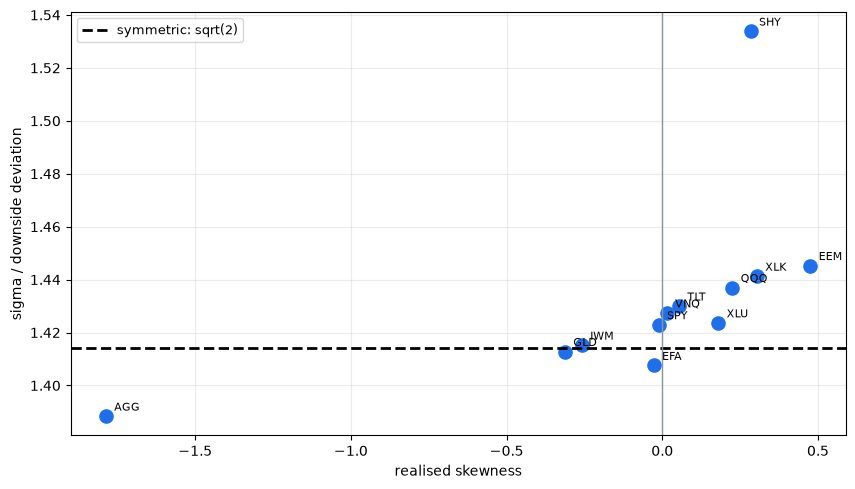

         skew  sd_over_dd  excess
asset                            
SPY   -0.0116      1.4229  0.0087
QQQ    0.2251      1.4370  0.0228
IWM   -0.2583      1.4152  0.0010
EFA   -0.0274      1.4075 -0.0067
EEM    0.4756      1.4453  0.0311
AGG   -1.7869      1.3884 -0.0258
TLT    0.0539      1.4300  0.0158
GLD   -0.3125      1.4128 -0.0014
VNQ    0.0147      1.4274  0.0132
XLU    0.1801      1.4236  0.0094
XLK    0.3038      1.4413  0.0271
SHY    0.2840      1.5338  0.1196

correlation between skew and the departure: +0.5507


In [5]:
dvs = st.disagreement_vs_skew(R)
fig, ax = plt.subplots(figsize=(10, 5.5))
ax.scatter(dvs["skew"], dvs["sd_over_dd"], s=90, color="#1f6feb")
for name, row in dvs.iterrows():
    ax.annotate(name, (row["skew"], row["sd_over_dd"]), fontsize=8,
                xytext=(6, 4), textcoords="offset points")
ax.axhline(np.sqrt(2), color="k", ls="--", lw=2, label="symmetric: sqrt(2)")
ax.axvline(0, color="#8b949e", lw=1)
ax.set_xlabel("realised skewness")
ax.set_ylabel("sigma / downside deviation"); ax.legend(fontsize=9)
plt.show()
print(dvs.round(4).to_string())
print(f"\ncorrelation between skew and the departure: "
      f"{dvs.attrs['corr_skew_excess']:+.4f}")

> \U0001F4A1 **In plain words.** Every point is close to the dashed line, and the small
> departures line up with skewness exactly as the theory says. That is a mechanism confirmed —
> and a very narrow range within which the two ratios can disagree at all.

### 3.3 Precision, bootstrapped on identical resamples

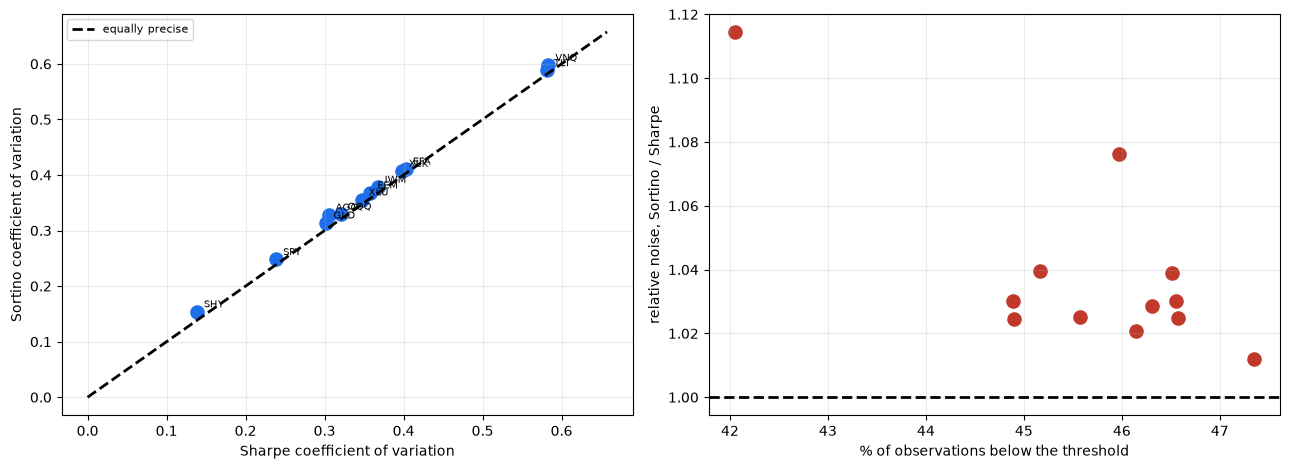

       below_share  sharpe_se  sortino_se  sharpe_cv  sortino_cv  noise_ratio
asset                                                                        
SPY         0.4516     0.1552      0.2302     0.2388      0.2482       1.0397
QQQ         0.4489     0.1659      0.2464     0.3205      0.3301       1.0302
IWM         0.4655     0.1728      0.2530     0.3673      0.3784       1.0302
EFA         0.4615     0.1754      0.2535     0.4029      0.4113       1.0209
EEM         0.4631     0.1759      0.2621     0.3580      0.3683       1.0287
AGG         0.4597     0.1953      0.2957     0.3052      0.3285       1.0763
TLT         0.4735     0.1873      0.2729     0.5814      0.5884       1.0119
GLD         0.4651     0.1955      0.2884     0.3024      0.3142       1.0390
VNQ         0.4657     0.1947      0.2885     0.5833      0.5978       1.0248
XLU         0.4558     0.1670      0.2446     0.3470      0.3557       1.0251
XLK         0.4490     0.1838      0.2727     0.3977      0.4074

In [6]:
rows = []
for c in R.columns:
    p = st.estimation_precision(R[c].dropna().to_numpy(), n_boot=500)
    if p:
        rows.append({"asset": c, **p})
d = pd.DataFrame(rows).set_index("asset")
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
axes[0].scatter(d["sharpe_cv"], d["sortino_cv"], s=90, color="#1f6feb")
lim = [0, max(d[["sharpe_cv", "sortino_cv"]].max()) * 1.1]
axes[0].plot(lim, lim, "k--", lw=2, label="equally precise")
for name, row in d.iterrows():
    axes[0].annotate(name, (row["sharpe_cv"], row["sortino_cv"]), fontsize=7,
                     xytext=(5, 3), textcoords="offset points")
axes[0].set_xlabel("Sharpe coefficient of variation")
axes[0].set_ylabel("Sortino coefficient of variation"); axes[0].legend(fontsize=8)
axes[1].scatter(d["below_share"] * 100, d["noise_ratio"], s=90, color="#c0392b")
axes[1].axhline(1.0, color="k", ls="--", lw=2)
axes[1].set_xlabel("% of observations below the threshold")
axes[1].set_ylabel("relative noise, Sortino / Sharpe")
plt.tight_layout(); plt.show()
print(d[["below_share", "sharpe_se", "sortino_se", "sharpe_cv", "sortino_cv",
         "noise_ratio"]].round(4).to_string())

### 3.4 How well is skewness known? — the decisive section

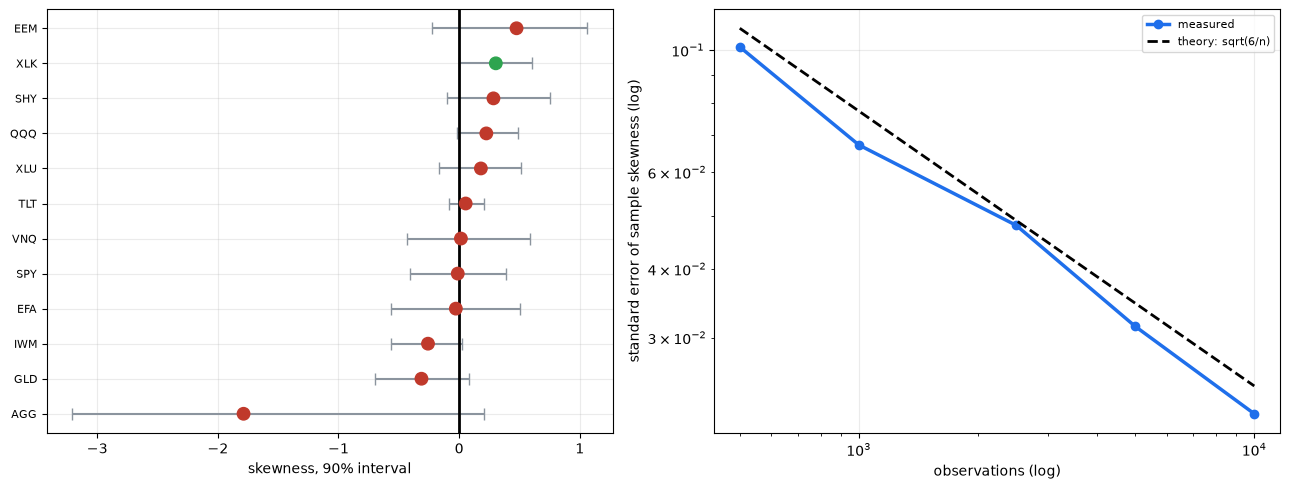

         skew  boot_mean     se     p05    p95  spans_zero       t
asset                                                             
AGG   -1.7869    -1.5512 1.0514 -3.2050 0.2045        True -1.4754
GLD   -0.3125    -0.3270 0.2387 -0.6948 0.0848        True -1.3701
IWM   -0.2583    -0.2612 0.1839 -0.5674 0.0219        True -1.4199
EFA   -0.0274    -0.0406 0.3216 -0.5672 0.5005        True -0.1262
SPY   -0.0116    -0.0172 0.2424 -0.4058 0.3885        True -0.0709
VNQ    0.0147     0.0480 0.3120 -0.4322 0.5902        True  0.1540
TLT    0.0539     0.0540 0.0896 -0.0869 0.2092        True  0.6028
XLU    0.1801     0.1712 0.2141 -0.1710 0.5123        True  0.7996
QQQ    0.2251     0.2248 0.1540 -0.0206 0.4908        True  1.4594
SHY    0.2840     0.2902 0.2571 -0.1011 0.7537        True  1.1285
XLK    0.3038     0.2960 0.1849  0.0004 0.6055       False  1.6006
EEM    0.4756     0.4023 0.3922 -0.2250 1.0590        True  1.0256


In [7]:
rows = []
for c in R.columns:
    s = st.skew_reliability(R[c].dropna().to_numpy(), n_boot=500)
    if s:
        rows.append({"asset": c, **s})
d = pd.DataFrame(rows).set_index("asset").sort_values("skew")
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
colors = ["#c0392b" if z else "#2ea44f" for z in d["spans_zero"]]
axes[0].errorbar(d["skew"], np.arange(len(d)),
                 xerr=[d["skew"] - d["p05"], d["p95"] - d["skew"]],
                 fmt="none", capsize=4, color="#8b949e")
axes[0].scatter(d["skew"], np.arange(len(d)), s=80, c=colors, zorder=3)
axes[0].axvline(0, color="k", lw=2)
axes[0].set_yticks(np.arange(len(d))); axes[0].set_yticklabels(d.index, fontsize=8)
axes[0].set_xlabel("skewness, 90% interval")
ns = [500, 1000, 2500, 5000, 10000]
ses = []
for n in ns:
    draws = [float(pd.Series(st.synthetic_skewed(n=n, target_skew=0.0, seed=k)).skew())
             for k in range(60)]
    ses.append(np.std(draws, ddof=1))
axes[1].loglog(ns, ses, "o-", lw=2.5, color="#1f6feb", label="measured")
axes[1].loglog(ns, np.sqrt(6 / np.array(ns)), "k--", lw=2,
               label="theory: sqrt(6/n)")
axes[1].set_xlabel("observations (log)")
axes[1].set_ylabel("standard error of sample skewness (log)")
axes[1].legend(fontsize=8)
plt.tight_layout(); plt.show()
print(d.round(4).to_string())

> \U0001F4A1 **In plain words.** The right panel is the general problem: the standard error of
> sample skewness falls like √(6/n), so distinguishing a skew of 0.1 from zero needs about six
> hundred observations under normality — and far more with fat tails, which is the case that
> matters. The left panel is what that means for this panel.

### 3.5 The horse race, both scoreboards

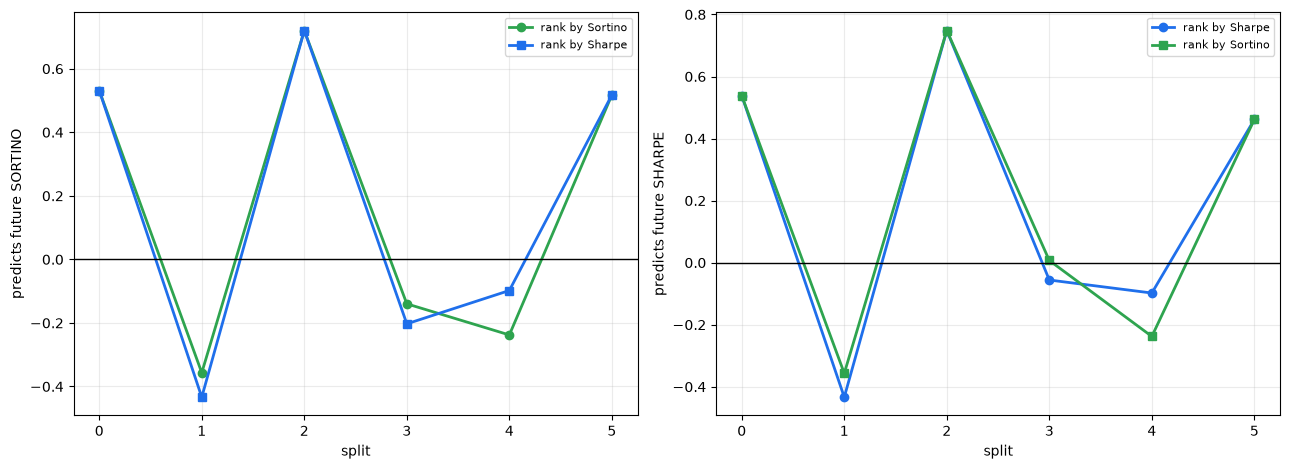

                   predicting future Sharpe  predicting future Sortino
ranked by Sharpe                     0.1935                     0.1725
ranked by Sortino                    0.1935                     0.1725

Sortino's edge on its own scoreboard: +0.0000


In [8]:
oos = st.out_of_sample_ranking(R, n_splits=7)
hr = st.horse_race_summary(oos)
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
axes[0].plot(oos["split"], oos["sortino_predicts_sortino"], "o-", lw=2,
             color="#2ea44f", label="rank by Sortino")
axes[0].plot(oos["split"], oos["sharpe_predicts_sortino"], "s-", lw=2,
             color="#1f6feb", label="rank by Sharpe")
axes[0].axhline(0, color="k", lw=1)
axes[0].set_xlabel("split"); axes[0].set_ylabel("predicts future SORTINO")
axes[0].legend(fontsize=8)
axes[1].plot(oos["split"], oos["sharpe_predicts_sharpe"], "o-", lw=2, color="#1f6feb",
             label="rank by Sharpe")
axes[1].plot(oos["split"], oos["sortino_predicts_sharpe"], "s-", lw=2, color="#2ea44f",
             label="rank by Sortino")
axes[1].axhline(0, color="k", lw=1)
axes[1].set_xlabel("split"); axes[1].set_ylabel("predicts future SHARPE")
axes[1].legend(fontsize=8)
plt.tight_layout(); plt.show()
print(pd.DataFrame({
    "predicting future Sharpe": [hr["sharpe_predicts_sharpe"],
                                 hr["sortino_predicts_sharpe"]],
    "predicting future Sortino": [hr["sharpe_predicts_sortino"],
                                  hr["sortino_predicts_sortino"]],
}, index=["ranked by Sharpe", "ranked by Sortino"]).round(4).to_string())
print(f"\nSortino's edge on its own scoreboard: {hr['sortino_edge_own_game']:+.4f}")

> \U0001F4A1 **In plain words.** The left panel is the fair test: which ranking better predicts
> *future downside-adjusted* performance? If the blue line matches the green one, then the
> ordinary Sharpe ratio is as good a predictor of Sortino as Sortino is, and the extra
> machinery has bought nothing.

### 3.6 The control: skew is the only lever

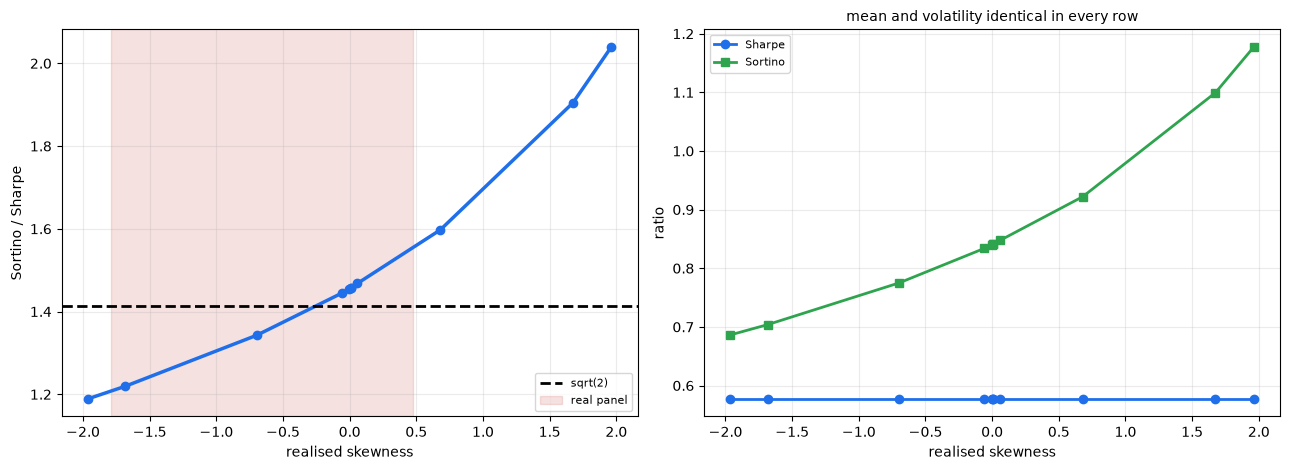

             realised_skew  sharpe  sortino  sortino_over_sharpe  symmetric_value
target_skew                                                                      
-2.5000            -1.9641  0.5773   0.6863               1.1889           1.4142
-1.5000            -1.6849  0.5773   0.7038               1.2193           1.4142
-1.0000            -0.6982  0.5773   0.7750               1.3426           1.4142
-0.5000            -0.0609  0.5773   0.8337               1.4443           1.4142
-0.2500            -0.0026  0.5773   0.8403               1.4556           1.4142
0.0000              0.0086  0.5773   0.8417               1.4580           1.4142
0.2500              0.0068  0.5773   0.8415               1.4578           1.4142
0.5000              0.0585  0.5773   0.8475               1.4681           1.4142
1.0000              0.6798  0.5773   0.9221               1.5974           1.4142
1.5000              1.6748  0.5773   1.0995               1.9046           1.4142
2.5000          

In [9]:
sw = st.skew_sweep(skews=(-2.5, -1.5, -1.0, -0.5, -0.25, 0.0, 0.25, 0.5,
                          1.0, 1.5, 2.5), n=50000, n_reps=6)
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
axes[0].plot(sw["realised_skew"], sw["sortino_over_sharpe"], "o-", lw=2.5,
             color="#1f6feb")
axes[0].axhline(np.sqrt(2), color="k", ls="--", lw=2, label="sqrt(2)")
real = st.ratio_table(R)["skew"]
axes[0].axvspan(real.min(), real.max(), alpha=0.15, color="#c0392b",
                label="real panel")
axes[0].set_xlabel("realised skewness"); axes[0].set_ylabel("Sortino / Sharpe")
axes[0].legend(fontsize=8)
axes[1].plot(sw["realised_skew"], sw["sharpe"], "o-", lw=2, color="#1f6feb",
             label="Sharpe")
axes[1].plot(sw["realised_skew"], sw["sortino"], "s-", lw=2, color="#2ea44f",
             label="Sortino")
axes[1].set_xlabel("realised skewness"); axes[1].set_ylabel("ratio")
axes[1].set_title("mean and volatility identical in every row", fontsize=10)
axes[1].legend(fontsize=8)
plt.tight_layout(); plt.show()
print(sw.round(4).to_string())

### 3.7 Does the threshold choice change anything?

In [10]:
rows = []
for mar_ann in (0.0, 0.02, 0.05, 0.08):
    mar = mar_ann / 252
    t = st.ratio_table(R, rf, mar)
    a = st.rank_agreement(t)
    rows.append({"mar": mar_ann, "spearman": a["spearman"],
                 "mean_rank_change": a["mean_abs_rank_change"],
                 "mean_sortino": t["sortino"].mean()})
d = pd.DataFrame(rows).set_index("mar")
print(d.round(4).to_string())
print()
print("A higher hurdle pushes more days below the threshold, which changes the level")
print("of every Sortino ratio. Whether it changes the RANKING is the column to read.")

        spearman  mean_rank_change  mean_sortino
mar                                             
0.0000    0.3217            2.8333        0.8046
0.0200    0.9930            0.1667        0.4789
0.0500    0.9860            0.3333        0.0290
0.0800    0.9301            1.1667       -0.3790

A higher hurdle pushes more days below the threshold, which changes the level
of every Sortino ratio. Whether it changes the RANKING is the column to read.


## 4 · The verdict

In [11]:
t = st.ratio_table(R, rf)
a = st.rank_agreement(t)
dvs = st.disagreement_vs_skew(R)
prec = pd.DataFrame([{"asset": c, **st.estimation_precision(
    R[c].dropna().to_numpy(), n_boot=300)} for c in R.columns
    if st.estimation_precision(R[c].dropna().to_numpy(), n_boot=50)]).set_index("asset")
skw = pd.DataFrame([{"asset": c, **st.skew_reliability(
    R[c].dropna().to_numpy(), n_boot=300)} for c in R.columns
    if st.skew_reliability(R[c].dropna().to_numpy(), n_boot=50)]).set_index("asset")
hr = st.horse_race_summary(st.out_of_sample_ranking(R, n_splits=7))
pd.DataFrame({
    "assets": [len(t)],
    "Spearman between the rankings": [a["spearman"]],
    "average rank change": [a["mean_abs_rank_change"]],
    "mean sigma / downside deviation": [dvs["sd_over_dd"].mean()],
    "the symmetric value": [np.sqrt(2)],
    "corr(skew, departure from sqrt2)": [dvs.attrs["corr_skew_excess"]],
    "share of days below the threshold": [prec["below_share"].mean()],
    "median relative noise, Sortino/Sharpe": [prec["noise_ratio"].median()],
    "share of assets whose skew CI spans zero": [skw["spans_zero"].mean()],
    "rank by Sortino -> future Sortino": [hr["sortino_predicts_sortino"]],
    "rank by Sharpe -> future Sortino": [hr["sharpe_predicts_sortino"]],
    "Sortino's edge on its own scoreboard": [hr["sortino_edge_own_game"]],
}).T.rename(columns={0: "value"}).round(4)

,value
assets,12.0000
Spearman between the rankings,0.3217
average rank change,2.8333
mean sigma / downside deviation,1.4321
the symmetric value,1.4142
"corr(skew, departure from sqrt2)",0.5507
share of days below the threshold,0.4567
"median relative noise, Sortino/Sharpe",1.0295
share of assets whose skew CI spans zero,0.9167
rank by Sortino -> future Sortino,0.1725


## 5 · Going further

- **Eling & Schuhmacher (2007)** found rank correlations near one across a dozen performance
  measures on hedge funds; §3.2 gives the arithmetic reason why, which their paper documents
  empirically without deriving.
- **Zakamouline (2011)** is the dissent worth reading: he argues the agreement is a property of
  the samples rather than of the measures. The way to settle it is §3.6 with a wider skew range
  than real assets provide, which is what the control is for.
- **Where Sortino should win** is option-like payoffs — covered calls, put selling, merger
  arbitrage — whose skew is large, structural and therefore better identified than an index's.
  Running §3.5 on such a panel is the natural sequel and the fair test of the ratio.
- **Robust skewness estimators** (Kim & White 2004) would tighten §3.4's intervals considerably
  and might change the conclusion. If the distinguishing input can be measured better, the
  distinguishing ratio becomes more useful — which is a more constructive route than arguing
  about denominators.